In [2]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import pandas as pd
import seaborn as sns

from connectivity.curves import CURVES


%load_ext autoreload
%autoreload 2
%aimport connectivity

base_path = "D:/data_paper"
patient_id = "EL012"
SOURCE = "output" #"publish_data/paper" # "output"
CLEAN_DATA_FILE = "out/clean_Ph_IO/bad_responses_dict.json"
RESPONSES_FILE = f"../{SOURCE}/pharmaco/response_channels_lf.json"
PHARMACO_RESULTS_FILE = f"../{SOURCE}/pharmaco/pharmaco_result_lf.json"
BASELINE_CORRECTION = True
SNR_COLUMN = "snr"
CURVE = CURVES["5P"]
SIGNIFICANCE_LEVEL = 0.05
R_SQUARED_THRESHOLD = 0.6
SIGNIFICANCE_COL = "p_surrogate_fdr_corrected" # "p_surrogate_fdr_corrected"

def format_p(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


Excluded 3 noisy channels.
Excluded 25 WM-only channels.
Excluded 6 out/putament/ventricle channels.
xmin 0.0 xmax 4.697265625000001
low r squared fits: 47 , of which are  10  failed fits.
Empty DataFrame
Columns: [patient_id, stim_channel_name, response_channel_name, delta_exi, p_empirical, p_surrogate, on_r_squared, off_r_squared, delta_empirical_exi, p_surrogate_fdr_corrected]
Index: []
Total connections after filtering: 74
74 37 0 37


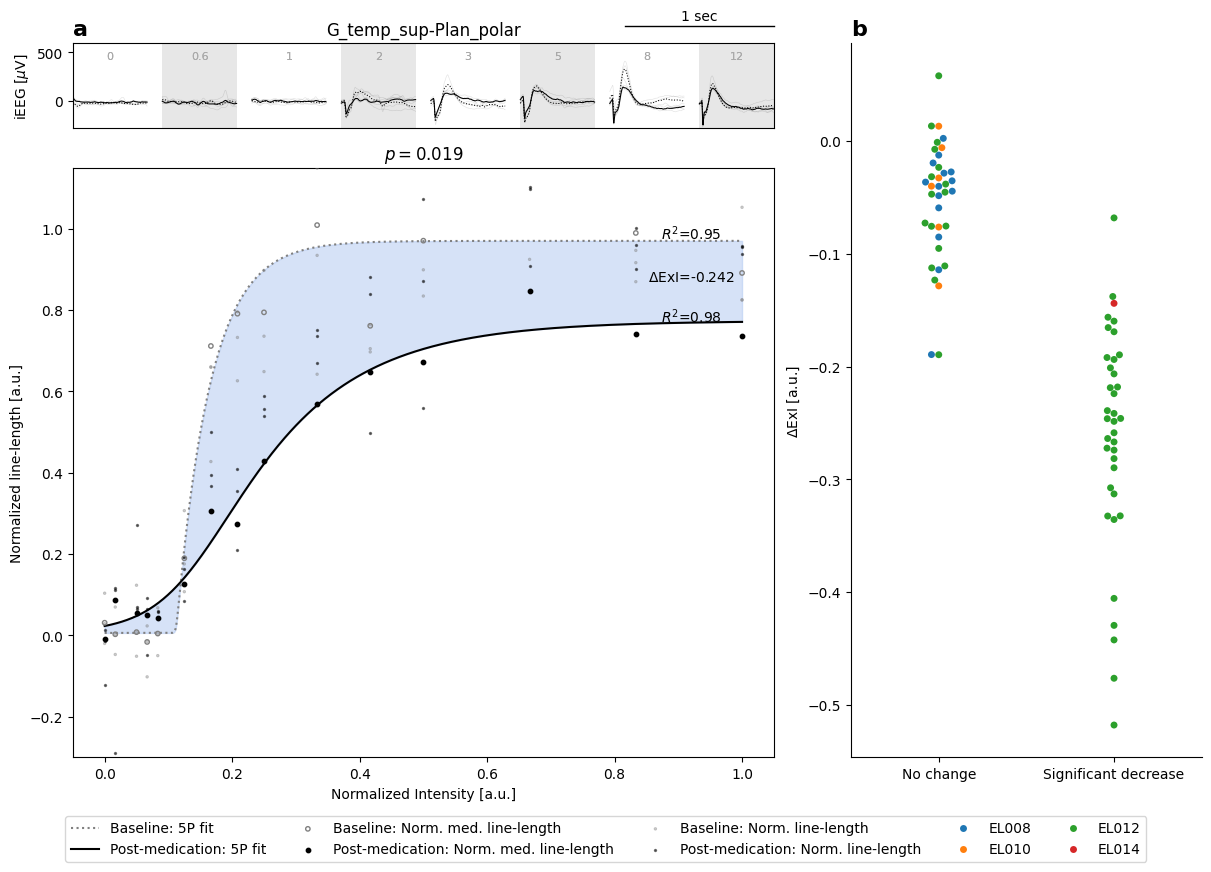

In [6]:
# raw traces
from matplotlib.legend_handler import HandlerTuple
from matplotlib.legend_handler import HandlerTuple
from matplotlib.patches import Rectangle
import scipy
from connectivity.analyze import (
    calculate_continuous_line_length,
    filter_logs,
    fit_curve,
    normalize_ll_values,
)
from connectivity.enums import SleepStage
from connectivity.load import MultipleHDFResponseLoader, get_h5_names_of_patient, parsed_list_to_numpy_array
from connectivity.analyze import calculate_model_performance
import matplotlib.lines as mlines

stim_channel_name_pos = "aH_L-1"
stim_channel_name_neg = "aH_L-2"
response_channel_pair = ("TP_L-3", "TP_L-4")

friendly_response_channel_name = "TP-L-3-4"

def format_p(p):
    return "p < 0.001" if p < 0.001 else f"p = {p:.3f}"


names_h5 = get_h5_names_of_patient(base_path, patient_id, protocol="Ph")
path_lookup = f"{base_path}/{patient_id}/Electrodes/Lookup.xlsx"
paths_h5 = [f"{base_path}/{patient_id}/Electrophy/{name}.h5" for name in names_h5]
paths_logs = [f"{base_path}/{patient_id}/out/{name}_logs.csv" for name in names_h5]
path_excluded_responses = f"{base_path}/{patient_id}/{CLEAN_DATA_FILE}"

mrl = MultipleHDFResponseLoader(
    paths_h5=paths_h5,
    paths_logs=paths_logs,
    recording_names=names_h5,
    path_lookup=path_lookup,
    path_excluded_responses=path_excluded_responses,
)

logs = mrl.get_logs()

all_response_channels = mrl.get_channel_paths(
    exclude_noisy_channels=True,
    exclude_stim_channels=True,
    stim_channel_name_pos=stim_channel_name_pos,
    stim_channel_name_neg=stim_channel_name_neg,
    exclude_out_channels=True,
    exclude_wm_only_channels=True
)

responses_df = pd.read_json(RESPONSES_FILE, orient="records")
pharmaco_df = pd.read_json(PHARMACO_RESULTS_FILE, orient="records")

# FDR-correction
patient_ids = pharmaco_df["patient_id"].unique()
for pat_id in patient_ids:
    maks = pharmaco_df[pharmaco_df["patient_id"] == pat_id]
    p_values = maks["p_surrogate"]
    p_values[p_values.isna()] = 1 # set NaNs to 1
    spearman_p_values_fdr_corrected = scipy.stats.false_discovery_control(
            p_values, method="bh"
    )
    pharmaco_df.loc[maks.index, "p_surrogate_fdr_corrected"] = spearman_p_values_fdr_corrected

friendly_condition_names = {
    "on": "Post-medication",
    "off": "Baseline",
}
colors = {
    "on": "black",
    "off": "gray",
}
linestyles = {
    "on": "solid",
    "off": "dotted",
}
markers = {
    "on": {"marker": "o", "facecolors": "black"}, # filled
    "off": {"marker": "o", "facecolors": "none"}, # empty
}
x_fit = np.linspace(0, 1, 1000)


def plot_stimulation_response_curve(
    stim_channel_name_pos,
    stim_channel_name_neg,
    response_channel_pair,
    ax_u,
    ax_ll,
):
    response_channel_name_pos = response_channel_pair[0]
    response_channel_name_neg = response_channel_pair[1]
    response_channel_name = response_channel_name_pos + "-" + response_channel_name_neg

    stim_channel_name = stim_channel_name_pos + "-" + stim_channel_name_neg

    response_channel_path = mrl.get_channel_paths_from_names(
        channel_names=[response_channel_name]
    )[0]

    io_intensities = (
        logs[logs["type"] == "Ph_IO"]["Int_prob"].drop_duplicates().tolist()
    )
    io_intensities.sort()
    io_intensities.insert(0, 0)

    y_fits = {}
    exis = {}
    for condition in ["off", "on"]:
        result_dict = responses_df[
            (responses_df["patient_id"] == patient_id) &
            (responses_df["stim_channel_name"] == stim_channel_name) &
            (responses_df["response_channel_name"] == response_channel_name) &
            (responses_df["condition"] == condition)
        ].squeeze()
     
        # RAW TRACES
        id_matrix = result_dict["id_matrix"]
        id_matrix = np.array(id_matrix)  # shape: n_intensities, n_replications
        ind_matrix = mrl.get_inds_from_stim_ids(id_matrix)
        
        gap_sec = 0.1  # seconds between chunks
        gap = int(round(gap_sec * mrl.f_sample))
        ll_window_start = round(
            1 * mrl.f_sample
        )  # we only want to have the [0, 0.5s] window to display, as it is used for LL calculation
        ll_window_end = round(1.5 * mrl.f_sample)
        chunk_len = ll_window_end - ll_window_start  # traces.shape[3]
        total_chunks = id_matrix.shape[0] // 2 + 1
        time = np.arange(chunk_len * total_chunks) / mrl.f_sample

        # Plot each chunk with color-coded significance
        for j in range(total_chunks):
            if j == 0:
                # remove the -0.6s in the end of every index that indicates baseline
                cleaned_ids = [s.replace("-0.6s", "") for s in id_matrix[2*j]]
                cleaned_inds = mrl.get_inds_from_stim_ids(cleaned_ids)

                traces = mrl.get_responses(
                    stim_indices=cleaned_inds,
                    response_channel_paths=[response_channel_path],
                    t_start=-1-0.6,
                    t_stop=1-0.6,
                    overwrite_excluded_recordings=True, 
                ).squeeze(
                    1
                )  # shape: n_replications, 1, n_time,

                traces_chunk = traces[:, ll_window_start:ll_window_end]
            else:
                max_j = min(2*j, id_matrix.shape[0]-1)

                traces = mrl.get_responses(
                    stim_indices=ind_matrix[max_j],
                    response_channel_paths=[response_channel_path],
                    # overwrite_excluded_recordings=exclude_responses,
                    t_start=-1,
                    t_stop=1,
                    overwrite_excluded_recordings=True,
                ).squeeze(
                    1
                )  # shape: n_replications, 1, n_time, remove middle dim
                traces_chunk = traces[:, ll_window_start:ll_window_end]
            avg_trace_chunk = np.nanmean(traces_chunk, axis=0)  # shape: n_time

            start_idx = j * chunk_len
            end_idx = (j + 1) * chunk_len
            offset_chunk = j * (chunk_len + gap)
            time_chunk = (np.arange(chunk_len) + offset_chunk) / mrl.f_sample

            for trace in traces_chunk:
                ax_u.plot(time_chunk, trace, color="black", alpha=0.1, linewidth=0.5)
            ax_u.plot(
                time_chunk,
                avg_trace_chunk,
                color="black",
                linestyle=linestyles[condition],
                linewidth=0.75,
            )

            start = offset_chunk / mrl.f_sample
            end = (offset_chunk + chunk_len) / mrl.f_sample
            ax_u.axvspan(
                start,
                end,
                facecolor=("lightgray" if j % 2 else "white"),
                alpha=0.3,
                zorder=0,
            ) 
        # stim annotation
        y_axes = 0.91
        for j in range(total_chunks):
            max_j = min(2*j, id_matrix.shape[0]-1)
            offset_chunk = j * (chunk_len + gap)
            start = offset_chunk / mrl.f_sample
            end = (offset_chunk + chunk_len) / mrl.f_sample
            x_center = 0.5 * (start + end)
            ax_u.text(
                x_center,
                y_axes,
                f"{io_intensities[max_j]:.2g}",
                ha="center",
                va="top",
                color="darkgray",
                fontsize=8,
                transform=ax_u.get_xaxis_transform(),  # x=data, y=axes
            )
        ymin, ymax = ax_u.get_ylim()
        headroom = 0.1 * (ymax - ymin)  # fraction of current range
        ax_u.set_ylim(ymin, ymax + headroom)
        ax_u.margins(x=0, y=0)

        # STIMULATION RESPONSE CURVE
        norm_intensities = np.array(io_intensities) / max(io_intensities)
        ll_values = parsed_list_to_numpy_array(result_dict["ll_values"])
        norm_med_lls = parsed_list_to_numpy_array(result_dict["norm_ll_med_values"])
        med_ll_values = np.nanmedian(ll_values, axis=1)

        shared_ll_min = 0
        shared_ll_max = np.nanpercentile(med_ll_values, 95, axis=0)
        norm_lls = normalize_ll_values(
            ll_values=parsed_list_to_numpy_array(ll_values),
            max=shared_ll_max,
            min=shared_ll_min,
            use_min=True,
            axis=0,
        )

        ax_ll.scatter(
            norm_intensities, norm_med_lls, color=colors[condition], s=10, label=f"{friendly_condition_names[condition]}: Norm. med. line-length", zorder=7, **markers[condition]
        )
        for j in range(norm_lls.shape[1]):
            ax_ll.scatter(norm_intensities, norm_lls[:, j], color=colors[condition], alpha=0.5, s=2, zorder=6, label=f"{friendly_condition_names[condition]}: Norm. line-length" if j==0 else "_nolegend_", **markers[condition])

        # fit curve manually
        x_fit = np.linspace(0, 1, 1000)
        try:
            params = fit_curve(
                curve_function=CURVE["function"],
                x=norm_intensities,
                y=norm_med_lls,
                initial_values=CURVE["initial_values"],
                bounds=CURVE["bounds"],
            )
            y_pred = CURVE["function"](norm_intensities, *params)
            performance_dict = calculate_model_performance(
                y=norm_med_lls,
                y_pred=y_pred,
                num_params=len(CURVE["initial_values"]) + 1,
            )
            y_fit = CURVE["function"](x_fit, *params)
            ax_ll.plot(
                x_fit,
                y_fit,
                label=f"{friendly_condition_names[condition]}: {CURVE['name']} fit",
                color=colors[condition],
                linestyle=linestyles[condition]
            )
            ax_ll.text(
                0.92, # hard coded position
                y_fit[int(0.85 * len(x_fit))] + 0.02,
                f"$R^2$=" + f"{performance_dict['r_squared']:.2f}",
                ha="center",
                va="center",
            )
            exi = np.trapezoid(y_fit, x_fit)

            y_fits[condition] = y_fit
            exis[condition] = exi

        except Exception as e:
            print("Curve fitting failed", e)


        if condition == "on":
            res = pharmaco_df[
                (pharmaco_df["patient_id"] == patient_id) &
                (pharmaco_df["stim_channel_name"] == stim_channel_name) &
                (pharmaco_df["response_channel_name"] == response_channel_name)
            ].squeeze()
            ax_ll.set_ylabel("Normalized line-length [a.u.]")
            ax_ll.set_xlabel("Normalized Intensity [a.u.]")
            ax_ll.set_title(f"${format_p(res[SIGNIFICANCE_COL])}$")
            
            ax_ll.fill_between(
                x_fit,
                y_fits["off"],
                y_fits["on"],
                color="#aec6f1",
                alpha=0.5,
                zorder=0
            )
            ax_ll.text(
                0.92, # hard coded position
                0.88,
                f"$\\Delta$ExI=" + f"{exis['on'] - exis['off']:.3f}",
                ha="center",
                va="center",
            )

            ax_u.set_ylabel("iEEG $\\left[\\mu \\mathrm{V}\\right]$")
            ax_u.set_xticks([])
            
centralized_legend_handles = []
centralized_legend_labels = []

fig = plt.figure(figsize=(12, 8), constrained_layout=True)
gs = GridSpec(
    2, 2, figure=fig, height_ratios=[1, 7], width_ratios=[2, 1]
)

ax_au = fig.add_subplot(gs[0, 0])
ax_al = fig.add_subplot(gs[1, 0])
plot_stimulation_response_curve(
        stim_channel_name_pos=stim_channel_name_pos,
        stim_channel_name_neg=stim_channel_name_neg,
        response_channel_pair=response_channel_pair,
        ax_u=ax_au,
        ax_ll=ax_al,
    )
ax_au.set_title("a", loc='left', fontsize=16, fontweight='bold')
pad_frac = 0
y_frac = 1.2

xmin, xmax = ax_au.get_xlim()
print("xmin", xmin, "xmax", xmax)
x1 = xmax - pad_frac * (xmax - xmin)  # right-aligned
x0 = x1 - 1 # max length - 1 sec
ax_au.plot(
    [x0, x1], [y_frac, y_frac],
    transform=ax_au.get_xaxis_transform(),
    color="black", lw=1,
    clip_on=False
)
ax_au.text(
    (x0 + x1) / 2, y_frac + 0.04,
    f"1 sec",
    transform=ax_au.get_xaxis_transform(),
    ha="center", va="bottom",
    clip_on=False
)


destr_label = mrl.get_destrieux_labels_from_names(channel_names=[response_channel_pair[0] + "-" + response_channel_pair[1]], short_form=True)[0]
ax_au.set_title(f"{destr_label}")
#ax_au.set_title(f"{friendly_response_channel_name} ({destr_label})")
ax_al.set_ylim([-0.3, 1.15])

handles, labels = ax_al.get_legend_handles_labels()
centralized_legend_handles.extend(handles)
centralized_legend_labels.extend(labels)

n_no_connection = len(responses_df[(responses_df["condition"] == "on") & (responses_df["combined_significant"] == False)])  # no significant change
n_connection = len(responses_df[(responses_df["condition"] == "on") & (responses_df["combined_significant"] == True)])
n_low_r_squared = len(pharmaco_df[(pharmaco_df["on_r_squared"] < R_SQUARED_THRESHOLD) | (pharmaco_df["off_r_squared"] < R_SQUARED_THRESHOLD)])
print("low r squared fits:", n_low_r_squared, ", of which are ", len(pharmaco_df[pharmaco_df["delta_exi"].isna()]), " failed fits.")
assert n_connection == len(pharmaco_df)
n_no_connection += n_low_r_squared # add low R^2 fits to no connection
n_connection -= n_low_r_squared # remove low R^2 fits from connections

filtered_pharmaco_df = pharmaco_df[(pharmaco_df["on_r_squared"] >= R_SQUARED_THRESHOLD) & (pharmaco_df["off_r_squared"] >= R_SQUARED_THRESHOLD)]

assert len(filtered_pharmaco_df[filtered_pharmaco_df["delta_exi"].isna()]) == 0, "There are NaN delta ExI values in the filtered pharmaco df"
print(filtered_pharmaco_df[filtered_pharmaco_df["p_surrogate"].isna()])
assert len(filtered_pharmaco_df[filtered_pharmaco_df["p_surrogate"].isna()]) == 0

print("Total connections after filtering:", len(filtered_pharmaco_df))
n_significant_decrease = len(filtered_pharmaco_df[(filtered_pharmaco_df["delta_exi"] < 0) & (filtered_pharmaco_df[SIGNIFICANCE_COL] <= SIGNIFICANCE_LEVEL)])
n_significant_increase = len(filtered_pharmaco_df[(filtered_pharmaco_df["delta_exi"] >= 0) & (filtered_pharmaco_df[SIGNIFICANCE_COL] <= SIGNIFICANCE_LEVEL)])
n_no_change = len(filtered_pharmaco_df[(filtered_pharmaco_df[SIGNIFICANCE_COL] > SIGNIFICANCE_LEVEL)])
print(n_connection, n_significant_decrease, n_significant_increase, n_no_change)

# values = [n_no_connection, n_significant_decrease, n_no_change, n_significant_increase]
# labels = [f"No connection\n(n={n_no_connection})",  f"Connection - Decrease\n(n={n_significant_decrease})", f"Connection - No change\n(n={n_no_change})", f"Connection - Increase\n(n={n_significant_increase})"]


ax_b = fig.add_subplot(gs[:, 1])
ax_b.set_title("b", loc='left', fontsize=16, fontweight='bold')
filtered_pharmaco_df["significant_difference"] = np.where(
    filtered_pharmaco_df[SIGNIFICANCE_COL] <= SIGNIFICANCE_LEVEL,
    "Significant decrease",
    "No change",
)

# significant_mask = filtered_pharmaco_df[SIGNIFICANCE_COL] <= SIGNIFICANCE_LEVEL
# non_significant_mask = filtered_pharmaco_df[SIGNIFICANCE_COL] > SIGNIFICANCE_LEVEL

cmap = plt.get_cmap("tab10")
colors = {pat_id: cmap(i) for i, pat_id in enumerate(patient_ids)}
    
tmp = sns.swarmplot(
    data=filtered_pharmaco_df,
    x="significant_difference",
    y="delta_exi",
    hue="patient_id",
    size=5, ## scatter has to be squared
    ax=ax_b,
)
xlim = tmp.get_xlim()
# positions for each point (size == n)
offsets = []
for coll in tmp.collections:
    offsets.append(coll.get_offsets())

offsets = np.vstack(offsets)   # shape (n, 2)

x_positions = offsets[:, 0]
y_positions = offsets[:, 1]


ax_b.set_ylabel("$\\Delta$ExI [a.u.]")
ax_b.set_xlabel("")
# sns.move_legend(
#     ax_b,
#     "lower left",
#     bbox_to_anchor=(-2.5, 0),
# )
ax_b.set_title("b", loc='left', fontsize=16, fontweight='bold')
ax_b.spines["top"].set_visible(False)
ax_b.spines["right"].set_visible(False)
participant_handles, participant_labels = ax_b.get_legend_handles_labels()
ax_b.legend().remove()


order = [2, 5, 0, 3, 1, 4] 
centralized_legend_handles = [centralized_legend_handles[i] for i in order]
centralized_legend_labels  = [centralized_legend_labels[i]  for i in order]
centralized_legend_handles.extend(participant_handles)
centralized_legend_labels.extend(participant_labels)
# centralized_legend_handles[6:6] = participant_handles[2:]
# centralized_legend_labels[6:6] = participant_labels[2:]

fig.legend(
    centralized_legend_handles,
    centralized_legend_labels,
    loc="lower center",
    ncol=5,
    bbox_to_anchor=(0.5, -0.08),
    frameon=True,
)
# legend_2 = fig.legend(
#     participant_handles,
#     participant_labels,
#     loc="lower center",
#     ncol=2,
#     bbox_to_anchor=(0.5, -0.08),
#     frameon=False,
# )



plt.savefig("../output/figures/figure5.pdf", bbox_inches='tight', dpi=300)
plt.savefig("../output/figures/figure5.svg", bbox_inches='tight', dpi=300)
plt.show()